# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [2]:
# Example: generate 10 uniform random numbers between 0 and 1
example_uniform = np.random.uniform(low=0, high=1, size=10)
example_uniform

array([0.60877578, 0.87834651, 0.50188617, 0.12258653, 0.21429301,
       0.45959804, 0.14455786, 0.20889191, 0.84593101, 0.17333769])

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

In [3]:
def generate_uniform(bottom, ceiling, count):
    """
    Generate `count` uniformly distributed random numbers
    between `bottom` and `ceiling`.
    """
    return np.random.uniform(low=bottom, high=ceiling, size=count)

In [4]:
# First set of parameters
uniform_10_15_100 = generate_uniform(bottom=10, ceiling=15, count=100)

# Second set of parameters
uniform_10_60_1000 = generate_uniform(bottom=10, ceiling=60, count=1000)

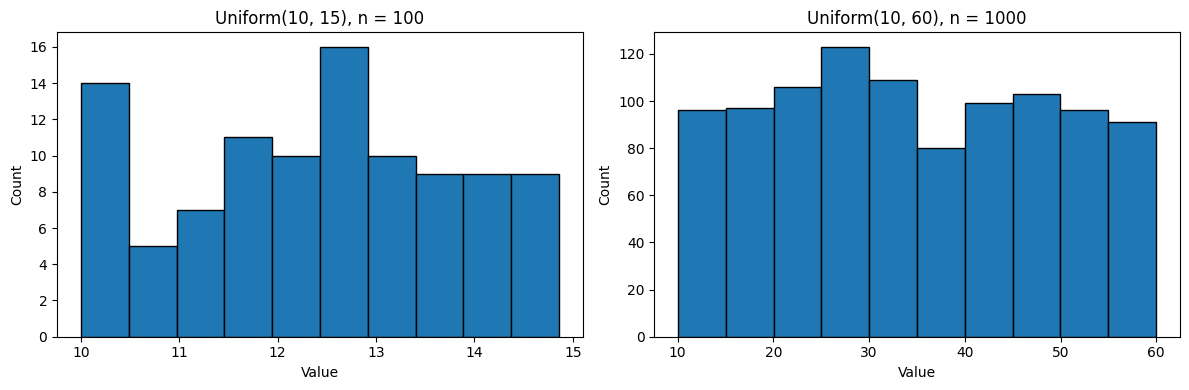

In [5]:
plt.figure(figsize=(12, 4))

# Distribution 1: 10–15, 100 samples
plt.subplot(1, 2, 1)
plt.hist(uniform_10_15_100, bins=10, edgecolor="black")
plt.title("Uniform(10, 15), n = 100")
plt.xlabel("Value")
plt.ylabel("Count")

# Distribution 2: 10–60, 1000 samples
plt.subplot(1, 2, 2)
plt.hist(uniform_10_60_1000, bins=10, edgecolor="black")
plt.title("Uniform(10, 60), n = 1000")
plt.xlabel("Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

How are the two distributions different?

In [6]:
# The first distribution (10 to 15) is concentrated in a narrow range, so the histogram bars are tall and close together.
# The second one (10 to 60) is spread over a much wider range, so the bars are spread out and each bin contains fewer observations.
# Both are roughly flat (uniform), but the scales and spreads are very different.

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [7]:
from scipy.stats import norm 

In [8]:
def generate_normal(mean, std, count):
    """
    Generate `count` normally distributed random numbers
    with given mean and standard deviation.
    """
    return norm.rvs(loc=mean, scale=std, size=count)

In [9]:
normal_10_1 = generate_normal(mean=10, std=1, count=1000)
normal_10_50 = generate_normal(mean=10, std=50, count=1000)

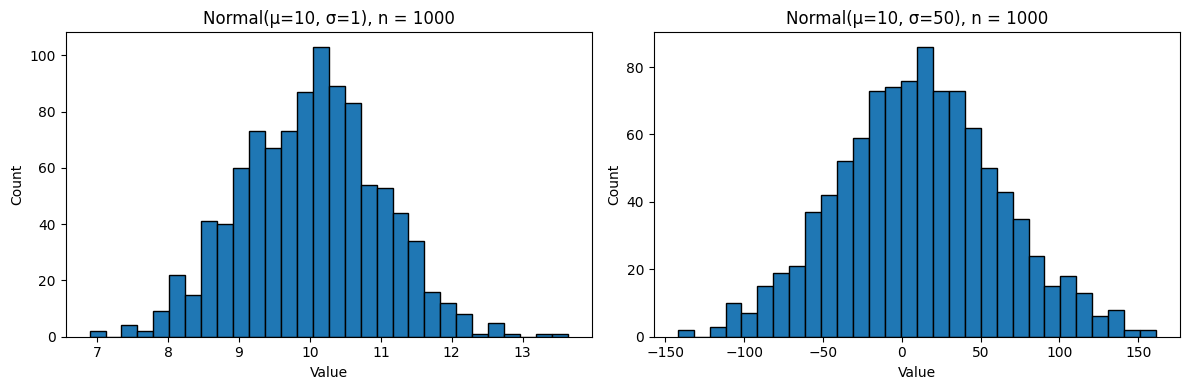

In [10]:
plt.figure(figsize=(12, 4))

# σ = 1
plt.subplot(1, 2, 1)
plt.hist(normal_10_1, bins=30, edgecolor="black")
plt.title("Normal(μ=10, σ=1), n = 1000")
plt.xlabel("Value")
plt.ylabel("Count")

# σ = 50
plt.subplot(1, 2, 2)
plt.hist(normal_10_50, bins=30, edgecolor="black")
plt.title("Normal(μ=10, σ=50), n = 1000")
plt.xlabel("Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [11]:
print("Sample mean/std for σ=1 :", np.mean(normal_10_1), np.std(normal_10_1))
print("Sample mean/std for σ=50:", np.mean(normal_10_50), np.std(normal_10_50))

Sample mean/std for σ=1 : 10.014270121680674 0.9811210001773614
Sample mean/std for σ=50: 10.946575581594217 51.1799426802403


How are the two distributions different?

In [12]:
# Both distributions are centered around 10 (same mean), but the one with σ=50 is much more spread out and flatter,
# while the one with σ=1 is much more concentrated and sharply peaked.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [13]:
vehicles = pd.read_csv("vehicles.csv")
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

In [14]:
fuel_barrels = vehicles["Fuel Barrels/Year"].dropna()
fuel_barrels.head()

0    19.388824
1    25.354615
2    20.600625
3    25.354615
4    20.600625
Name: Fuel Barrels/Year, dtype: float64

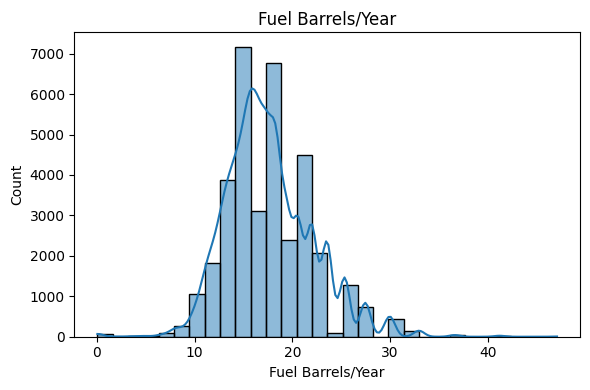

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(fuel_barrels, bins=30, kde=True)
plt.title("Fuel Barrels/Year")
plt.xlabel("Fuel Barrels/Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

2. CO2 Emission Grams/Mile 

In [16]:
co2 = vehicles["CO2 Emission Grams/Mile"].dropna()
co2.head()

0    522.764706
1    683.615385
2    555.437500
3    683.615385
4    555.437500
Name: CO2 Emission Grams/Mile, dtype: float64

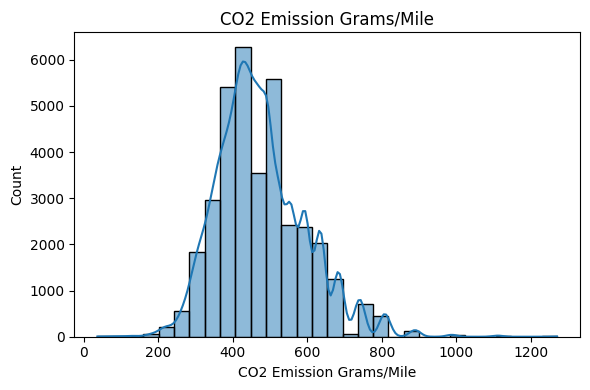

In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(co2, bins=30, kde=True)
plt.title("CO2 Emission Grams/Mile")
plt.xlabel("CO2 Emission Grams/Mile")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

3. Combined MPG

In [18]:
combined_mpg = vehicles["Combined MPG"].dropna()
combined_mpg.head()

0    17
1    13
2    16
3    13
4    16
Name: Combined MPG, dtype: int64

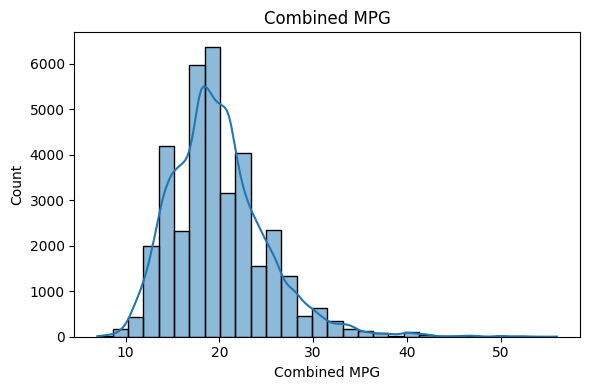

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(combined_mpg, bins=30, kde=True)
plt.title("Combined MPG")
plt.xlabel("Combined MPG")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Which one(s) of the variables are nearly normally distributed? How do you know?

In [20]:
# All three variables (Fuel Barrels/Year, CO2 Emission Grams/Mile, and Combined MPG)
# show a roughly bell-shaped distribution, but all of them have a noticeable right skew.
# Because of this skew, none of the variables follow a perfect normal distribution.

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

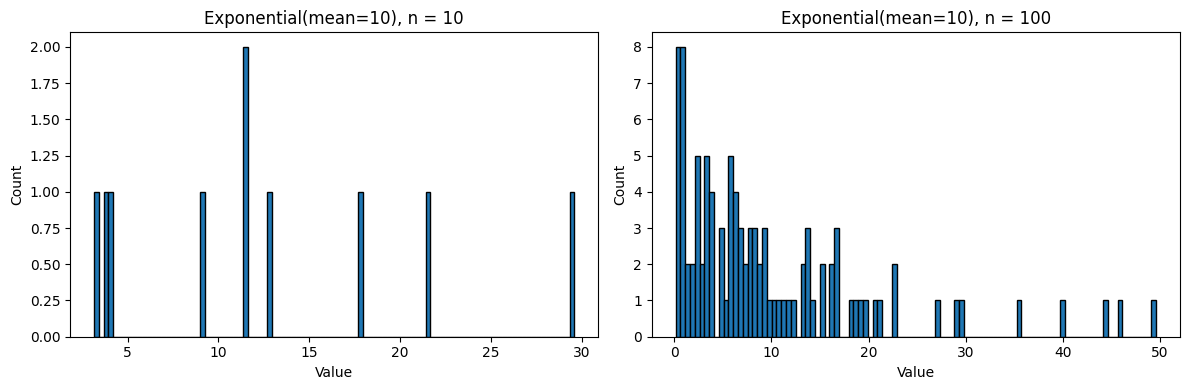

In [21]:
def generate_exponential(mean, size):
    """
    Generate `size` exponentially distributed random numbers
    with a given mean (scale).
    """
    return np.random.exponential(scale=mean, size=size)

# Generate sequences with mean 10
exp_10 = generate_exponential(mean=10, size=10)
exp_100 = generate_exponential(mean=10, size=100)

plt.figure(figsize=(12, 4))

# n = 10
plt.subplot(1, 2, 1)
plt.hist(exp_10, bins=100, edgecolor="black")
plt.title("Exponential(mean=10), n = 10")
plt.xlabel("Value")
plt.ylabel("Count")

# n = 100
plt.subplot(1, 2, 2)
plt.hist(exp_100, bins=100, edgecolor="black")
plt.title("Exponential(mean=10), n = 100")
plt.xlabel("Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

How are the two distributions different?

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [22]:
mean_time = 10      # mean time in minutes
x = 15              # threshold in minutes
lambda_param = 1 / mean_time

# For an exponential distribution: P(X < x) = 1 - exp(-λ x)
prob_less_15 = 1 - np.exp(-lambda_param * x)
print(f"Probability that a customer spends less than {x} minutes: {prob_less_15:.4f}")

Probability that a customer spends less than 15 minutes: 0.7769


What is the probability that the customer will spend more than 15 minutes

In [23]:
# P(X > 15) = 1 - P(X < 15)
prob_more_15 = 1 - prob_less_15
print(f"Probability that a customer spends more than 15 minutes: {prob_more_15:.4f}")

Probability that a customer spends more than 15 minutes: 0.2231
